# R square on Linear regression
The figure below shows 4 different case: the points are spread more in the begining and less spread towards last figure. Notice how R square value changes

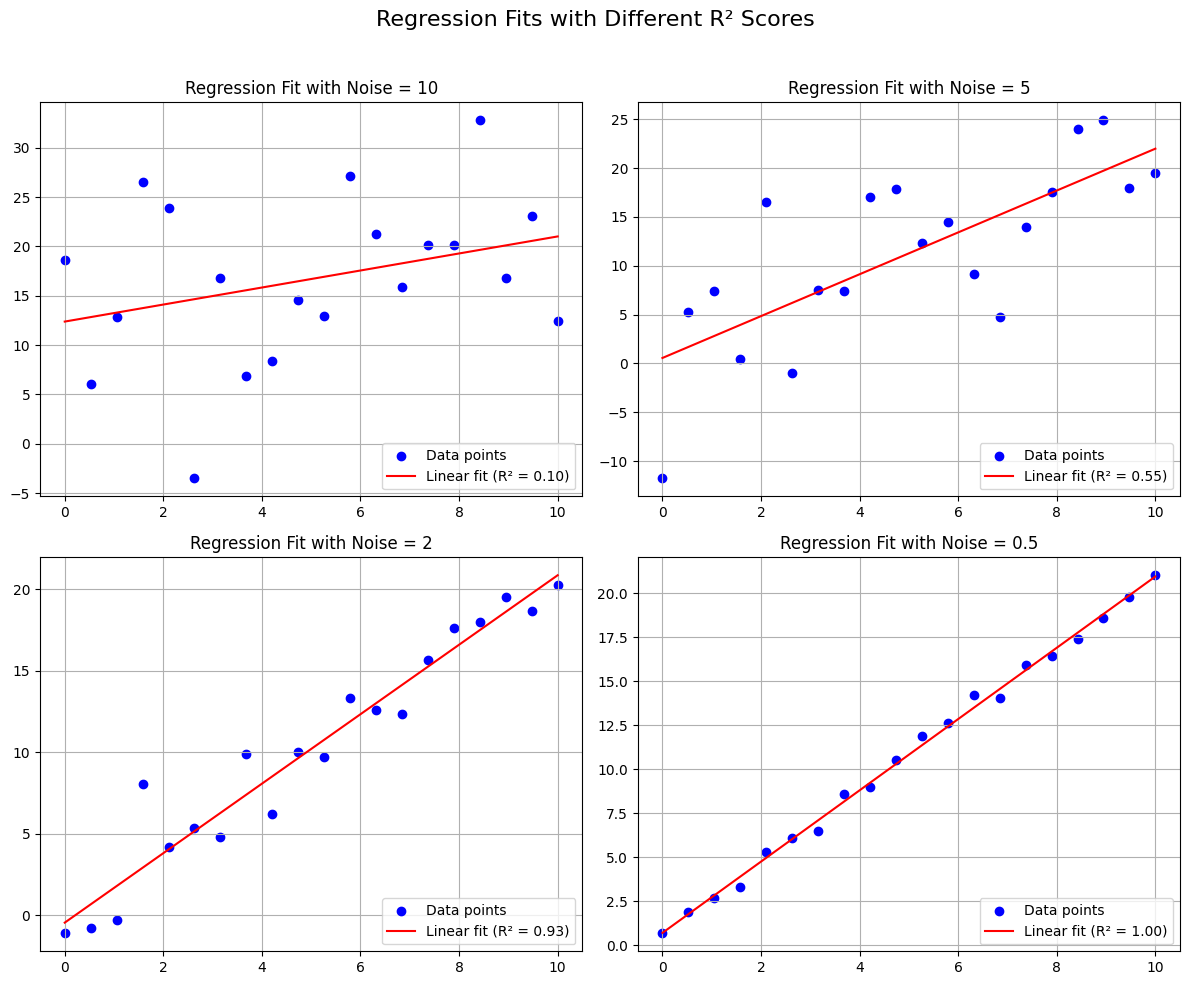

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

np.random.seed(0)

def generate_data(noise_scale, pattern='linear'):
    x = np.linspace(0, 10, 20)
    if pattern == 'linear':
        y = 2 * x + 1 + np.random.normal(0, noise_scale, x.shape)
    return x.reshape(-1, 1), y

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
noise_levels = [10, 5, 2, 0.5]
titles = []

for i, ax in enumerate(axs.ravel()):
    x, y = generate_data(noise_levels[i])
    model = LinearRegression()
    model.fit(x, y)
    y_pred = model.predict(x)
    r2 = r2_score(y, y_pred)
    
    ax.scatter(x, y, color='blue', label='Data points')
    ax.plot(x, y_pred, color='red', label=f'Linear fit (R² = {r2:.2f})')
    ax.set_title(f'Regression Fit with Noise = {noise_levels[i]}')
    ax.legend(loc='lower right')
    ax.grid(True)

plt.suptitle("Regression Fits with Different R² Scores", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# R square on non  linear data

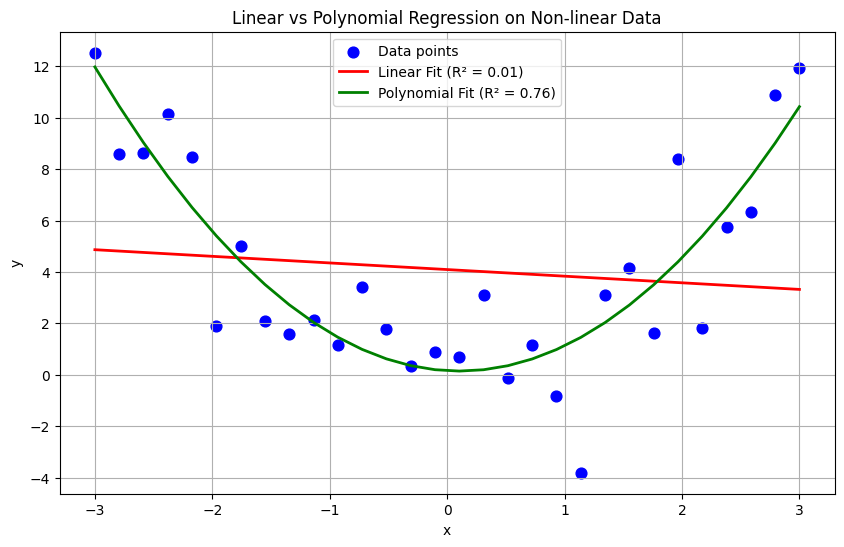

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

# Generate nonlinear data
np.random.seed(0)
x = np.linspace(-3, 3, 30)
y = x**2 + np.random.normal(0, 2, x.shape)  # y = x^2 + noise

x = x.reshape(-1, 1)

# Fit linear regression
lin_reg = LinearRegression()
lin_reg.fit(x, y)
y_pred_lin = lin_reg.predict(x)
r2_lin = r2_score(y, y_pred_lin)

# Fit polynomial regression (degree 2)
poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_model.fit(x, y)
y_pred_poly = poly_model.predict(x)
r2_poly = r2_score(y, y_pred_poly)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label="Data points", color="blue", s=60)
plt.plot(x, y_pred_lin, label=f"Linear Fit (R² = {r2_lin:.2f})", color="red", linewidth=2)
plt.plot(x, y_pred_poly, label=f"Polynomial Fit (R² = {r2_poly:.2f})", color="green", linewidth=2)
plt.title("Linear vs Polynomial Regression on Non-linear Data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc="upper center")
plt.grid(True)
plt.show()
